In [47]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image

import matplotlib.pyplot as plt


In [48]:
# Absoluter Projektpfad
PROJECT_ROOT = Path("/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning").resolve()
print("PROJECT_ROOT:", PROJECT_ROOT)

# (optional) Arbeitsverzeichnis setzen
os.chdir(PROJECT_ROOT)
print("cwd:", os.getcwd())

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

# CSV liegt jetzt direkt in dataset2
CSV_PATH = PROJECT_ROOT / "dataset2" / "Multi-Label dataset - with augmented.csv"
print("CSV_PATH:", CSV_PATH)

df_raw = pd.read_csv(CSV_PATH)
print("df_raw shape:", df_raw.shape)
print("Spalten:", df_raw.columns.tolist())
df_raw.head()


PROJECT_ROOT: /Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning
cwd: /Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning
CSV_PATH: /Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning/dataset2/Multi-Label dataset - with augmented.csv
df_raw shape: (5653, 12)
Spalten: ['dataset', 'filename', 'path', 'Early blight', 'Healthy', 'Late blight', 'Leaf Miner', 'Magnesium Deficiency', 'Nitrogen Deficiency', 'Pottassium Deficiency', 'Spotted Wilt Virus', 'SUM']


,dataset,filename,path,Early blight,Healthy,Late blight,Leaf Miner,Magnesium Deficiency,Nitrogen Deficiency,Pottassium Deficiency,Spotted Wilt Virus,SUM
0,test,IMG20220323100545_1.jpg,\test\Early_blight,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,test,IMG20220323102226_1.jpg,\test\Early_blight,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,test,IMG20220323102423_7.jpg,\test\Early_blight,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,test,IMG20220323102851_4.jpg,\test\Early_blight,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,test,IMG20220323103905_4.jpg,\test\Early_blight,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [49]:
# Nur Krankheiten (Healthy + SUM ignorieren)
DISEASE_COLS = [
    "Early blight",
    "Late blight",
    "Leaf Miner",
    "Magnesium Deficiency",
    "Nitrogen Deficiency",
    "Pottassium Deficiency",
    "Spotted Wilt Virus",
]

# Falls sich Spalten minimal anders schreiben, filtern wir auf tatsächlich vorhandene
DISEASE_COLS = [c for c in DISEASE_COLS if c in df_raw.columns]
NUM_LABELS   = len(DISEASE_COLS)
print("Verwendete Krankheits-Labels:", DISEASE_COLS)
print("NUM_LABELS:", NUM_LABELS)

# NaN -> 0, alles float32
df_raw[DISEASE_COLS] = df_raw[DISEASE_COLS].fillna(0).astype("float32")

# Basisordner für alle Multi-Label-Bilder
BASE_DIR = PROJECT_ROOT / "dataset2"
print("BASE_DIR:", BASE_DIR)

# 1) Index: (split, filename) -> voller Pfad
index = {}

for split in ["train", "val", "test"]:
    split_dir = BASE_DIR / split
    if not split_dir.is_dir():
        print(f"Warnung: {split_dir} existiert nicht")
        continue

    for p in split_dir.rglob("*"):
        if p.is_file():
            key = (split, p.name)       # z.B. ("train", "IMG2022....jpg")
            index[key] = str(p)

print("Anzahl Dateien im Index:", len(index))

# 2) CSV mit diesem Index verknüpfen
df = df_raw.copy()

def lookup_filepath(row):
    key = (str(row["dataset"]), str(row["filename"]))
    return index.get(key, None)

df["filepath"] = df.apply(lookup_filepath, axis=1)

missing = df["filepath"].isna().sum()
print("Zeilen ohne gefundenen Pfad:", missing)

# 3) Nur Zeilen mit gültigem Pfad behalten
df = df[df["filepath"].notna()].reset_index(drop=True)
print("df nach Filterung:", df.shape)

# 4) In train / val / test splitten
train_df = df[df["dataset"] == "train"].reset_index(drop=True)
val_df   = df[df["dataset"] == "val"].reset_index(drop=True)
test_df  = df[df["dataset"] == "test"].reset_index(drop=True)

print("\nAnzahl Samples:")
print("  train_df:", len(train_df))
print("  val_df:  ", len(val_df))
print("  test_df: ", len(test_df))

df[["dataset", "filename", "filepath"]].head()


Verwendete Krankheits-Labels: ['Early blight', 'Late blight', 'Leaf Miner', 'Magnesium Deficiency', 'Nitrogen Deficiency', 'Pottassium Deficiency', 'Spotted Wilt Virus']
NUM_LABELS: 7
BASE_DIR: /Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning/dataset2
Anzahl Dateien im Index: 5656
Zeilen ohne gefundenen Pfad: 0
df nach Filterung: (5653, 13)

Anzahl Samples:
  train_df: 3945
  val_df:   1124
  test_df:  584


,dataset,filename,filepath
0,test,IMG20220323100545_1.jpg,/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Proj...
1,test,IMG20220323102226_1.jpg,/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Proj...
2,test,IMG20220323102423_7.jpg,/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Proj...
3,test,IMG20220323102851_4.jpg,/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Proj...
4,test,IMG20220323103905_4.jpg,/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Proj...


In [50]:
def make_multilabel_dataset_from_df(df_split, shuffle=True):
    paths  = df_split["filepath"].values
    labels = df_split[DISEASE_COLS].values.astype("float32")  # (N, NUM_LABELS)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def _load_img(path, y):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        return img, y

    ds = ds.map(_load_img, num_parallel_calls=tf.data.AUTOTUNE)

    n = len(df_split)
    if shuffle and n > 0:
        ds = ds.shuffle(buffer_size=n, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_multilabel_dataset_from_df(train_df, shuffle=True)
val_ds   = make_multilabel_dataset_from_df(val_df,   shuffle=False)
test_ds  = make_multilabel_dataset_from_df(test_df,  shuffle=False)

# Check: kommt wirklich ein Batch?
for xb, yb in train_ds.take(1):
    print("Batch-Bilder:", xb.shape, "Batch-Labels:", yb.shape)


2025-11-26 22:29:00.979833: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [3945]
	 [[{{node Placeholder/_0}}]]
2025-11-26 22:29:00.980086: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [3945]
	 [[{{node Placeholder/_0}}]]


Batch-Bilder: (32, 224, 224, 3) Batch-Labels: (32, 7)


In [51]:
def make_plant_cnn_multilabel(input_shape=IMG_SIZE + (3,)):
    inputs = keras.Input(shape=input_shape)

    data_aug = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomBrightness(0.2),
        layers.RandomContrast(0.2),
    ], name="data_augmentation")

    x = data_aug(inputs)
    x = layers.Rescaling(1./255, name="rescale")(x)

    # Block 1
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 4 (optional)
    x = layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Dropout(0.5)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    # Multi-Label Output: NUM_LABELS Neuronen mit Sigmoid
    outputs = layers.Dense(
        NUM_LABELS,
        activation="sigmoid",
        name="multilabel_output"
    )(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="plant_cnn_multilabel")
    return model

plant_cnn = make_plant_cnn_multilabel()
plant_cnn.summary()


Model: "plant_cnn_multilabel"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequenti  (None, 224, 224, 3)      0         
 al)                                                             
                                                                 
 rescale (Rescaling)         (None, 224, 224, 3)       0         
                                                                 
 conv2d_35 (Conv2D)          (None, 224, 224, 32)      896       
                                                                 
 conv2d_36 (Conv2D)          (None, 224, 224, 32)      9248      
                                                                 
 max_pooling2d_20 (MaxPoolin  (None, 112, 112, 32)     0         
 g2D)                                         

In [52]:
plant_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",  # Multi-Label
    metrics=[
        keras.metrics.BinaryAccuracy(name="bin_acc"),
        keras.metrics.AUC(name="auc"),
    ],
    # zum Debuggen notfalls einschalten:
    # run_eagerly=True,
)

EPOCHS = 20

history = plant_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

plant_cnn.save("plant_cnn_from_scratch_multilabel_dataset2.keras")


Epoch 1/20


2025-11-26 22:29:02.681113: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [3945]
	 [[{{node Placeholder/_0}}]]
2025-11-26 22:29:02.681474: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [3945]
	 [[{{node Placeholder/_0}}]]
2025-11-26 22:29:03.507588: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-11-26 22:29:03.657665: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] model_pruner failed: INVALID_ARGUMENT: Graph does not contain termin

  1/124 [..............................] - ETA: 12:07 - loss: 0.6919 - bin_acc: 0.5089 - auc: 0.5257

2025-11-26 22:29:08.617491: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-11-26 22:29:08.618847: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


  2/124 [..............................] - ETA: 45s - loss: 0.6745 - bin_acc: 0.6473 - auc: 0.5731  

...

122/124 [============================>.] - ETA: 0s - loss: 2.0695 - bin_acc: 0.7855 - auc: 0.6521

2025-11-26 22:53:18.717101: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-11-26 22:53:18.717196: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


124/124 [==============================] - ETA: 0s - loss: 2.0636 - bin_acc: 0.7855 - auc: 0.6524

2025-11-26 22:53:19.043352: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-11-26 22:53:19.043377: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


124/124 [==============================] - 45s 352ms/step - loss: 2.0636 - bin_acc: 0.7855 - auc: 0.6524 - val_loss: 3.2270 - val_bin_acc: 0.7095 - val_auc: 0.6690


2025-11-26 22:56:07.539772: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 1s 659ms/step


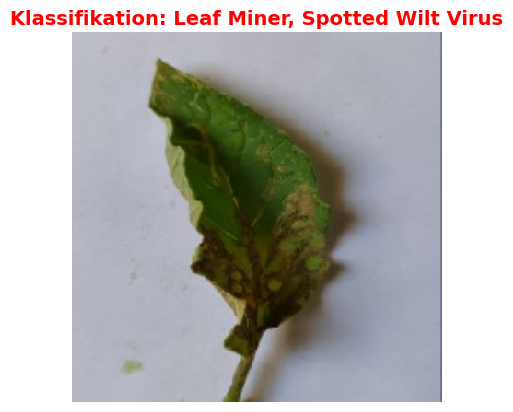

Scores pro Krankheit:
Early blight             : 0.000
Late blight              : 0.011
Leaf Miner               : 0.996
Magnesium Deficiency     : 0.000
Nitrogen Deficiency      : 0.000
Pottassium Deficiency    : 0.000
Spotted Wilt Virus       : 1.000

Schwellenwert: 0.5
Aktive Labels: Leaf Miner, Spotted Wilt Virus


In [54]:
# Modell laden (falls du zwischendurch neu startest)
plant_cnn = keras.models.load_model("plant_cnn_from_scratch_multilabel_dataset2.keras")

def predict_image_plant_cnn(img_path, model=plant_cnn, thresh=0.5):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    x = np.expand_dims(img_array, axis=0)  # kein /255 – Rescaling ist im Modell

    probs = model.predict(x)[0]  # (NUM_LABELS,)

    active_labels = [DISEASE_COLS[i] for i, p in enumerate(probs) if p >= thresh]

    if not active_labels:
        label_str = "keine Krankheit erkannt"
        color = "green"
    else:
        label_str = ", ".join(active_labels)
        color = "red"

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Klassifikation: {label_str}", color=color, fontsize=14, weight="bold")
    plt.show()

    print("Scores pro Krankheit:")
    for name, p in zip(DISEASE_COLS, probs):
        print(f"{name:25s}: {p:.3f}")
    print(f"\nSchwellenwert: {thresh}")
    print(f"Aktive Labels: {label_str}")

# Beispielaufruf (Pfad ggf. anpassen)
predict_image_plant_cnn(
    "/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning/dataset2/test/IMG20220323094749.jpg"
)
